# ANN Orchestrator For Multi-Run Ensembling and Checkpointing

This notebook defines a reusable orchestrator that:
1. Configures a set of runs (architectures, hyperparameters, number of seeds).
2. Runs expanding-window forecasts and top-k ensembling (same logic as `compute_top_k_ensemble`).
3. Saves model checkpoints at each refit step (DeepSHAP-friendly: torch `state_dict` + preprocessing state).
4. Saves performance tuples per maturity: `(maturity, r2_oos, rsz_pval)`.

The example at the bottom runs a simple forward-only ANN with `n_models=10` and `k_top=1`.

In [4]:
import os
import sys
from pathlib import Path
from dataclasses import dataclass, asdict
from datetime import datetime
from typing import Callable, Any

import numpy as np
import pandas as pd
import torch
import statsmodels.api as sm
from scipy.stats import t as tstat
from tqdm.auto import tqdm

sys.path.insert(0, os.path.abspath('..'))

import utils.base_utils as bu
import utils.window_utils as wu
from utils.macro_grouping import add_group_level, build_full_group_mapping

# Data prep
start_date = '1971-08-31'
end_date = '2018-12-31'
yield_data = 'lw' # Alternatively, 'kr' for Filipovic data
maturities = ['24', '36', '48', '60', '84', '120']
config_string = 'ANNUAL' # Alternatively, NO_ANNUAL for non-overlapping, or MONTHLY for monthly excess returns

# Scenario-level artifact root uses year-only labels to keep paths short and readable.
def _year_label(date_str: str) -> str:
    return str(pd.Timestamp(date_str).year)

experiment_name = f"run_{_year_label(start_date)}_{_year_label(end_date)}_{yield_data}_{config_string}"
experiment_artifacts_root = (Path('../artifacts/orchestrator_runs') / experiment_name).resolve()
experiment_artifacts_root.mkdir(parents=True, exist_ok=True)

yields = bu.get_yields(type='lw', start=start_date, end=end_date, maturities=[str(i) for i in range(12, 121) if i % 12 == 0]) # type can be kr, lw, gsw
forward = bu.get_forward_rates(yields)
xr = bu.get_excess_returns(yields, horizon=12).dropna() # horizon=12 means holding for 12 months

# adjust fred_md start_date by 6 months to fetch enough data for shifting
fred_md_start_date = pd.to_datetime(start_date) - pd.DateOffset(months=6)
fred_md_raw = bu.get_fred_data('data/2026-01-MD.csv', start=fred_md_start_date, end=end_date) # this is aligned to the last day of the previous month, so we get the same number of observations as the yields data

monthly_yields = bu.get_yields(type='lw', start=start_date, end=end_date, maturities=[str(i) for i in range(1, 121)]) # needed for monthly holding period excess returns. Not available for gsw
monthly_xr = bu.get_excess_returns(monthly_yields, horizon=1).dropna() # calculate monthly excess returns for robustness

# If wanted, apply per-series publication lag to latest-snapshot macro data
# For results in paper, where we naively shift all FRED-MD series by 1 month
# to reflect publication lag:
# from utils.publication_lags import apply_fred_md_publication_lag
# fred_md = apply_fred_md_publication_lag(fred_md_raw)  
fred_md = fred_md_raw.shift(1) 

# Drop TWEXAFEGSMTHx and ACOGNO as they start late
fred_md = fred_md.drop(columns=['TWEXAFEGSMTHx', 'ACOGNO'])
# Finally, revert fred_md to start_date, after transformations and lag adjustments
fred_md = fred_md[start_date:end_date]

# Drop dates outside the xr range
yields = yields.loc[yields.index <= xr.index[-1]]
forward = forward.loc[forward.index <= xr.index[-1]]
xr = xr.loc[xr.index <= xr.index[-1]]
fred_md = fred_md.loc[fred_md.index <= xr.index[-1]]
monthly_xr = monthly_xr.loc[monthly_xr.index <= xr.index[-1]]

# Construct X with 3-level MultiIndex: (source, group, series)
s2g = build_full_group_mapping(fred_md, forward, yields)

X = pd.concat([fred_md, forward, yields],
               axis=1,
               keys=['fred', 'forward', 'yields'])

X = add_group_level(X, s2g, level_name='group')
X = X.sort_index(axis=1, level='group')

y_all = xr[maturities].values
dates = xr.index

/home/ulrikts/Documents/NTNU/TIO4900-Replication/utils/macro_grouping.py:219: UserWarning: The following series are defined in get_fredmd_grouping() but are not present in the FRED-MD data: ['ACOGNO', 'TWEXAFEGSMTHx']. They may have been dropped or renamed.
  warnings.warn(
/home/ulrikts/Documents/NTNU/TIO4900-Replication/utils/macro_grouping.py:168: UserWarning: 2 entries in series_to_group are not present in the DataFrame columns: ['ACOGNO', 'TWEXAFEGSMTHx']
  warnings.warn(


In [5]:
def compute_top_k_ensemble(forecasts_array: np.ndarray, val_losses_array: np.ndarray, k: int):
    # Same ensembling logic as existing notebook code: top-k per maturity and date by val loss.
    T, n_seeds, n_outputs = forecasts_array.shape
    ensemble_forecast = np.full((T, n_outputs), np.nan)
    topk_indices = np.full((T, n_outputs, min(k, n_seeds)), -1, dtype=int)

    for t in range(T):
        for m in range(n_outputs):
            v_losses = val_losses_array[t, :, m]
            valid_idx = np.where(~np.isnan(v_losses))[0]
            if len(valid_idx) == 0:
                continue

            actual_k = min(k, len(valid_idx))
            sorted_valid_idx = valid_idx[np.argsort(v_losses[valid_idx])]
            selected = sorted_valid_idx[:actual_k]

            topk_indices[t, m, :actual_k] = selected
            ensemble_forecast[t, m] = np.mean(forecasts_array[t, selected, m], axis=0)

    return ensemble_forecast, topk_indices


def _extract_scaler_state(scaler: Any):
    if scaler is None:
        return None
    state = {}
    for attr in ['mean_', 'scale_', 'var_', 'n_samples_seen_', 'n_features_in_']:
        if hasattr(scaler, attr):
            val = getattr(scaler, attr)
            if isinstance(val, np.ndarray):
                state[attr] = val.copy()
            elif np.isscalar(val):
                state[attr] = val.item() if hasattr(val, 'item') else val
            else:
                state[attr] = val
    return state


def _extract_pca_state(pca: Any):
    if pca is None:
        return None
    state = {}
    for attr in ['components_', 'mean_', 'explained_variance_', 'explained_variance_ratio_', 'n_components_']:
        if hasattr(pca, attr):
            val = getattr(pca, attr)
            state[attr] = val.copy() if isinstance(val, np.ndarray) else val
    return state


def _estimate_model_size_mb(wrapper_model: torch.nn.Module) -> float:
    n_params = sum(p.numel() for p in wrapper_model.parameters())
    return (n_params * 4) / (1024 ** 2)

In [6]:
@dataclass
class RunConfig:
    run_name: str
    model_builder: Callable[[int], Any]
    n_models: int
    k_top: int
    maturities: list
    oos_start: pd.Timestamp
    gap: int = 0
    refit_freq: int = 1
    benchmark: str = 'hist_mean'
    rsz_maxlags: int = 12
    progress: bool = False
    artifacts_root: Path = Path('../artifacts/orchestrator_runs')


def _save_checkpoint(wrapper, seed: int, t_index: int, date_value, run_dir: Path) -> Path:
    ckpt_dir = run_dir / 'checkpoints' / f'seed_{seed:03d}'
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = ckpt_dir / f'step_{t_index:04d}_{pd.Timestamp(date_value).date()}.pt'

    x_scalers_macro_state = None
    if hasattr(wrapper, 'x_scalers_macro') and isinstance(wrapper.x_scalers_macro, dict):
        x_scalers_macro_state = {k: _extract_scaler_state(v) for k, v in wrapper.x_scalers_macro.items()}

    checkpoint = {
        'wrapper_class': wrapper.__class__.__name__,
        'wrapper_module': wrapper.__class__.__module__,
        'torch_state_dict': wrapper.model.state_dict() if hasattr(wrapper, 'model') and wrapper.model is not None else None,
        'best_params_': getattr(wrapper, 'best_params_', None),
        'fit_calls': getattr(wrapper, '_fit_calls', None),
        'x_scaler': _extract_scaler_state(getattr(wrapper, 'x_scaler', None)),
        'x_scaler_forward': _extract_scaler_state(getattr(wrapper, 'x_scaler_forward', None)),
        'x_scaler_fred': _extract_scaler_state(getattr(wrapper, 'x_scaler_fred', None)),
        'x_scalers_macro': x_scalers_macro_state,
        'y_scaler': _extract_scaler_state(getattr(wrapper, 'y_scaler', None)),
        'pca': _extract_pca_state(getattr(wrapper, 'pca', None)),
    }

    torch.save(checkpoint, ckpt_path)
    return ckpt_path


def run_experiment(cfg: RunConfig, X: pd.DataFrame, y_all: np.ndarray, dates: pd.DatetimeIndex):
    ts = datetime.now().strftime('%Y%m%d_%H%M%S')
    run_dir = (cfg.artifacts_root / cfg.run_name / ts).resolve()
    run_dir.mkdir(parents=True, exist_ok=True)

    T = len(dates)
    n_outputs = y_all.shape[1] if y_all.ndim > 1 else 1

    all_forecasts = []
    all_val_losses = []
    ckpt_manifest = []

    model_iter = range(cfg.n_models)
    if cfg.progress:
        model_iter = tqdm(model_iter, desc='Seeds')

    for seed in model_iter:
        model = cfg.model_builder(seed)
        val_losses_for_seed = np.full((T, n_outputs), np.nan)

        # This callback is triggered at each refit step by expanding_window.
        def save_cb(model, refit_i, t_index, date_value, **kwargs):
            if hasattr(model, 'val_loss_') and model.val_loss_ is not None:
                val_losses_for_seed[t_index] = model.val_loss_

            ckpt_path = _save_checkpoint(model, seed, t_index, date_value, run_dir)
            ckpt_manifest.append({
                'seed': seed,
                'refit_i': refit_i,
                't_index': int(t_index),
                'date': str(pd.Timestamp(date_value).date()),
                'checkpoint_path': str(ckpt_path),
            })

        y_forecast = wu.expanding_window(
            model, X, y_all, dates, cfg.oos_start,
            gap=cfg.gap,
            refit_freq=cfg.refit_freq,
            save_callback=save_cb,
            progress=False,
        )

        all_forecasts.append(y_forecast)
        all_val_losses.append(val_losses_for_seed)

    forecasts_arr = np.stack(all_forecasts, axis=1)
    losses_arr = np.stack(all_val_losses, axis=1)

    ensemble_forecast, topk_indices = compute_top_k_ensemble(forecasts_arr, losses_arr, cfg.k_top)

    r2s = wu.oos_r2(y_all, ensemble_forecast, benchmark=cfg.benchmark)
    pvals = np.array([bu.RSZ_Signif(y_all[:, i], ensemble_forecast[:, i])
                     for i in range(n_outputs)])

    performance_tuples = list(zip(cfg.maturities, r2s.tolist(), pvals.tolist()))

    # Persist arrays and metadata
    np.save(run_dir / 'forecasts_arr.npy', forecasts_arr)
    np.save(run_dir / 'losses_arr.npy', losses_arr)
    np.save(run_dir / 'ensemble_forecast.npy', ensemble_forecast)
    np.save(run_dir / 'topk_indices.npy', topk_indices)

    pd.DataFrame(ckpt_manifest).to_csv(run_dir / 'checkpoint_manifest.csv', index=False)
    perf_df = pd.DataFrame(performance_tuples, columns=['maturity', 'r2_oos', 'rsz_pval'])
    perf_df.to_csv(run_dir / 'performance.csv', index=False)

    serializable_cfg = asdict(cfg)
    serializable_cfg['model_builder'] = str(cfg.model_builder)
    serializable_cfg['artifacts_root'] = str(cfg.artifacts_root)
    pd.Series(serializable_cfg).to_json(run_dir / 'run_config.json', indent=2)

    # Storage summary
    ckpt_paths = list((run_dir / 'checkpoints').rglob('*.pt'))
    total_ckpt_bytes = sum(p.stat().st_size for p in ckpt_paths)

    summary = {
        'run_dir': str(run_dir),
        'num_checkpoints': len(ckpt_paths),
        'total_checkpoint_gb': total_ckpt_bytes / (1024 ** 3),
        'performance': performance_tuples,
        'forecasts_arr_shape': forecasts_arr.shape,
        'losses_arr_shape': losses_arr.shape,
    }

    return summary

Main block for running:

In [7]:
import csv
from models.ann_vector_validation import PyTorchMLPWrapper
from models.macro_forward_ann import MacroForwardANNWrapper
from models.group_ensemble_ann import GroupEnsembleANNWrapper

# Forward-only architectures requested:
# (3,), (5,), (7,), (3,3), (5,5), (7,7), (3,3,3), (5,5,5), (7,7,7), (5,4,3)
fwd_architectures = [
    (3,), (5,), (7,),
    (3, 3), (5, 5), (7, 7),
    (3, 3, 3), (5, 5, 5), (7, 7, 7),
    (5, 4, 3),
]

macro_architectures = [
    (32,),
    (32, 16),
    (32, 16, 8),
]

# Image-based specs: per-group hidden nodes and forward tower depth.
group_ensemble_specs = [
    # 1-layer group ensemble, forward rates direct (pass forward rates with identity mapping)
    {'arch_macro': (1,), 'arch_forward': ()},
    # 1-layer group ensemble, forward tower 1 layer (3 nodes)
    {'arch_macro': (1,), 'arch_forward': (3,)},
    # 2-layer group ensemble (2,1), forward tower 2 layers (3,3)
    {'arch_macro': (2, 1), 'arch_forward': (3, 3)},
    # 3-layer group ensemble (3,2,1), forward tower 3 layers (3,3,3)
    {'arch_macro': (3, 2, 1), 'arch_forward': (3, 3, 3)},
]

def arch_to_name(arch):
    return 'direct' if len(arch) == 0 else '&'.join(str(x) for x in arch)

def base_run_config(run_name, model_builder, n_models=100, k_top=10):
    return RunConfig(
        run_name=run_name,
        model_builder=model_builder,
        n_models=n_models,
        k_top=k_top,
        maturities=maturities,
        oos_start=pd.Timestamp('1990-01-31'),
        gap=0,
        refit_freq=1,
        benchmark='hist_mean',
        progress=True,
        artifacts_root=experiment_artifacts_root,
    )

def make_fwd_ann_cfg(arch, n_models=100, k_top=10):
    return base_run_config(
        run_name=f"fwd_ann_{arch_to_name(arch)}_{n_models}runs_top{k_top}",
        model_builder=lambda seed, arch=arch: PyTorchMLPWrapper(
            archi=arch,
            lr=0.01,
            epochs=1000,
            tune_every=60,
            patience=50,
            param_grid={'penalty': [0.01, 0.001, 0.0001]},
            seed=seed,
            use_pca=False,
            n_components=None,
            y_center=True,
        ),
        n_models=n_models,
        k_top=k_top,
    )

def make_macro_forward_cfg(arch_macro, arch_forward=(3,), n_models=100, k_top=10):
    return base_run_config(
        run_name=(
            f"macro_fwd_ann_fwd{arch_to_name(arch_forward)}_"
            f"macro{arch_to_name(arch_macro)}_{n_models}runs_top{k_top}"
        ),
        model_builder=lambda seed, arch_macro=arch_macro, arch_forward=arch_forward: MacroForwardANNWrapper(
            archi_forward=arch_forward,
            archi_macro=arch_macro,
            lr=0.01,
            epochs=1000,
            tune_every=60,
            patience=50,
            param_grid={'penalty': [0.001, 0.0001], 'dropout_rate': [0.0, 0.1, 0.3]},
            seed=seed,
            y_center=True,
        ),
        n_models=n_models,
        k_top=k_top,
    )

def make_group_ensemble_cfg(arch_macro, arch_forward, n_models=100, k_top=10):
    return base_run_config(
        run_name=(
            f"group_ens_ann_fwd{arch_to_name(arch_forward)}_"
            f"grp{arch_to_name(arch_macro)}_{n_models}runs_top{k_top}"
        ),
        model_builder=lambda seed, arch_macro=arch_macro, arch_forward=arch_forward: GroupEnsembleANNWrapper(
            archi_forward=arch_forward,
            archi_macro=arch_macro,
            lr=0.01,
            epochs=1000,
            tune_every=60,
            patience=50,
            param_grid={'penalty': [0.001, 0.0001], 'dropout_rate': [0.0, 0.1, 0.3]},
            seed=seed,
            y_center=True,
        ),
        n_models=n_models,
        k_top=k_top,
    )

run_configs = []

# Forward-only ANN grid (restricted list above).
run_configs += [make_fwd_ann_cfg(arch) for arch in fwd_architectures]

# Macro + forward two-tower ANN grid from init-style defaults.
run_configs += [make_macro_forward_cfg(arch_macro) for arch_macro in macro_architectures]

# Group-ensemble ANN grid from image specs + init-style defaults.
run_configs += [
    make_group_ensemble_cfg(spec['arch_macro'], spec['arch_forward'])
    for spec in group_ensemble_specs
]

run_configs = [make_fwd_ann_cfg((3,))]

master_summary_path = (experiment_artifacts_root / 'master_summary.csv').resolve()
master_summary_path.parent.mkdir(parents=True, exist_ok=True)

master_fields = [
    'timestamp', 'run_name', 'status', 'run_dir', 'num_checkpoints',
    'total_checkpoint_gb', 'forecasts_arr_shape', 'losses_arr_shape',
    'performance', 'error',
]

def append_master_summary(row_dict):
    write_header = not master_summary_path.exists()
    with open(master_summary_path, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=master_fields)
        if write_header:
            writer.writeheader()
        writer.writerow(row_dict)

all_summaries = []
failed_runs = []

for i, cfg in enumerate(run_configs, start=1):
    print(f"[{i}/{len(run_configs)}] Running {cfg.run_name} ...")
    ts_now = datetime.now().isoformat(timespec='seconds')

    try:
        summary = run_experiment(cfg, X, y_all, dates)
        all_summaries.append(summary)

        append_master_summary({
            'timestamp': ts_now,
            'run_name': cfg.run_name,
            'status': 'ok',
            'run_dir': summary.get('run_dir', ''),
            'num_checkpoints': summary.get('num_checkpoints', ''),
            'total_checkpoint_gb': summary.get('total_checkpoint_gb', ''),
            'forecasts_arr_shape': summary.get('forecasts_arr_shape', ''),
            'losses_arr_shape': summary.get('losses_arr_shape', ''),
            'performance': summary.get('performance', ''),
            'error': '',
        })

    except Exception as e:
        err = f"{type(e).__name__}: {e}"
        failed_runs.append({'run_name': cfg.run_name, 'error': err})
        print(f"FAILED {cfg.run_name} -> {err}")

        append_master_summary({
            'timestamp': ts_now,
            'run_name': cfg.run_name,
            'status': 'failed',
            'run_dir': '',
            'num_checkpoints': '',
            'total_checkpoint_gb': '',
            'forecasts_arr_shape': '',
            'losses_arr_shape': '',
            'performance': '',
            'error': err,
        })

print(f"Completed {len(all_summaries)} successful runs out of {len(run_configs)} total.")
print(f"Failed runs: {len(failed_runs)}")
print(f"Master summary: {master_summary_path}")

[1/1] Running fwd_ann_3_100runs_top10 ...


Seeds:   4%|▍         | 4/100 [00:49<19:39, 12.28s/it]


KeyboardInterrupt: 

## Companion: Reload One Checkpoint and Compute SHAP

This section verifies end-to-end compatibility by:
1. Loading one saved checkpoint from the orchestrator artifacts.
2. Reconstructing the forward-only ANN torch model from checkpoint weights.
3. Reapplying saved preprocessing (scaler and optional PCA).
4. Computing SHAP values for one chosen maturity and date.

Notes:
- This companion cell currently targets `PyTorchMLPWrapper` checkpoints.

Run dir: ../artifacts/orchestrator_runs/fwd_ann_pcc_4runs_top2/20260320_142422
Checkpoint: /home/ulrikts/Documents/NTNU/TIO4900-Replication/artifacts/orchestrator_runs/fwd_ann_pcc_4runs_top2/20260320_142422/checkpoints/seed_000/step_0497_2013-01-31.pt
Chosen date: 2013-01-31
Chosen maturity: 120
Chosen seed: 0
Inferred architecture: (3,)
Input feature space for SHAP: PCA components


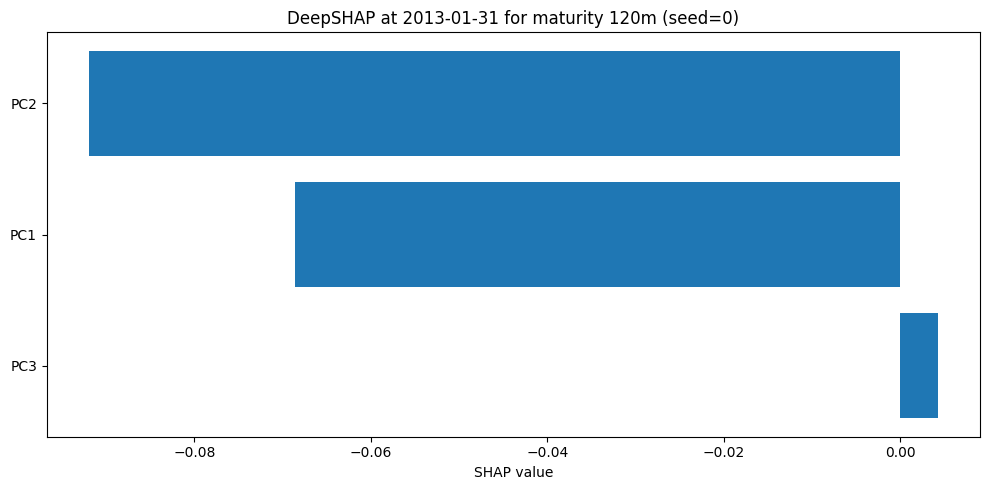

,feature,shap,abs_shap
1,PC2,-0.091927,0.091927
0,PC1,-0.068636,0.068636
2,PC3,0.004254,0.004254


In [ ]:
import importlib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import shap

# ---------- Artifact selection ----------
artifacts_root = experiment_artifacts_root
run_name = 'fwd_ann_pcc_4runs_top2'
run_timestamp = None  # None -> use latest run for this run_name
# ---------------------------------------

# ---------- User selections ----------
agg_maturity = chosen_maturity if 'chosen_maturity' in globals() else '120'
agg_date = chosen_date if 'chosen_date' in globals() else None
background_size = globals().get('background_size', 128)
# ------------------------------------


def resolve_run_dir(base_dir: Path, run_name: str, run_timestamp: str | None = None) -> Path:
    run_root = base_dir / run_name
    if not run_root.exists():
        raise FileNotFoundError(f'Run root does not exist: {run_root}')

    if run_timestamp is not None:
        run_dir = run_root / run_timestamp
        if not run_dir.exists():
            raise FileNotFoundError(f'Requested run timestamp not found: {run_dir}')
        return run_dir

    candidates = sorted([p for p in run_root.iterdir() if p.is_dir()])
    if not candidates:
        raise FileNotFoundError(f'No timestamped runs found under: {run_root}')
    return candidates[-1]


def apply_saved_preprocessing(X_raw, scaler_state, pca_state):
    Xp = np.asarray(X_raw, dtype=np.float32).copy()

    if scaler_state is not None:
        mean = scaler_state.get('mean_', None)
        scale = scaler_state.get('scale_', None)
        if mean is not None:
            Xp = Xp - np.asarray(mean, dtype=np.float32)
        if scale is not None:
            scale = np.asarray(scale, dtype=np.float32)
            scale = np.where(scale == 0.0, 1.0, scale)
            Xp = Xp / scale

    if pca_state is not None and pca_state.get('components_', None) is not None:
        pca_mean = pca_state.get('mean_', None)
        if pca_mean is not None:
            Xp = Xp - np.asarray(pca_mean, dtype=np.float32)
        comps = np.asarray(pca_state['components_'], dtype=np.float32)
        Xp = Xp @ comps.T

    return Xp


run_dir = resolve_run_dir(artifacts_root, run_name, run_timestamp)
manifest = pd.read_csv(run_dir / 'checkpoint_manifest.csv')
topk_indices = np.load(run_dir / 'topk_indices.npy')
if agg_maturity not in maturities:
    raise ValueError(f'agg_maturity={agg_maturity} not found in maturities list')

m_idx = maturities.index(agg_maturity)

# Resolve the date to explain.
if agg_date is None:
    valid_t = np.where(topk_indices[:, m_idx, 0] >= 0)[0]
    if len(valid_t) == 0:
        raise RuntimeError('No valid top-k selection found for this maturity.')
    t_idx = int(valid_t[-1])
else:
    matches = np.where(pd.to_datetime(dates) == pd.Timestamp(agg_date))[0]
    if len(matches) == 0:
        raise ValueError(f'agg_date={agg_date} not found in dates.')
    t_idx = int(matches[0])

seed_candidates = topk_indices[t_idx, m_idx, :]
selected_seeds = [int(s) for s in seed_candidates if int(s) >= 0]
if not selected_seeds:
    raise RuntimeError('No valid seeds in top-k for the selected maturity/date.')

# Use the best top-k seed for the selected maturity/date.
seed = selected_seeds[0]
row = manifest[(manifest['seed'] == seed) & (manifest['t_index'] == t_idx)]
if row.empty:
    raise RuntimeError(f'No checkpoint row found for seed={seed}, t_index={t_idx}.')

ckpt_path = Path(row.iloc[0]['checkpoint_path'])
checkpoint = torch.load(ckpt_path, map_location='cpu', weights_only=False)
if checkpoint.get('wrapper_class') != 'PyTorchMLPWrapper':
    raise NotImplementedError('This companion cell currently supports PyTorchMLPWrapper checkpoints only.')

# Reconstruct the saved MLP architecture.
state_dict = checkpoint['torch_state_dict']
linear_keys = [k for k, v in state_dict.items() if k.endswith('.weight') and getattr(v, 'ndim', 0) == 2]
linear_keys = sorted(linear_keys, key=lambda k: int(k.split('.')[1]))
if len(linear_keys) < 2:
    raise RuntimeError('Unexpected state_dict format; could not infer network architecture.')

in_dim = int(state_dict[linear_keys[0]].shape[1])
out_dim = int(state_dict[linear_keys[-1]].shape[0])
hidden_arch = tuple(int(state_dict[k].shape[0]) for k in linear_keys[:-1])

ann_mod = importlib.import_module('models.ann_vector_validation')
NetworkCls = getattr(ann_mod, '_MLPNetwork')
model = NetworkCls(input_dim=in_dim, archi=hidden_arch, output_dim=out_dim)
model.load_state_dict(state_dict)
model.eval()

# Rebuild the exact input space for SHAP.
X_forward = X['forward'].values
X_proc = apply_saved_preprocessing(X_forward, checkpoint.get('x_scaler', None), checkpoint.get('pca', None))

train_end = max(1, t_idx)
bg_start = max(0, train_end - background_size)
X_bg = X_proc[bg_start:train_end]
X_eval = X_proc[t_idx:t_idx + 1]

if X_bg.shape[0] < 2:
    raise RuntimeError('Not enough background rows for SHAP. Choose a later date or increase sample size.')

bg_tensor = torch.tensor(X_bg, dtype=torch.float32)
eval_tensor = torch.tensor(X_eval, dtype=torch.float32)

explainer = shap.DeepExplainer(model, bg_tensor)
shap_values = explainer.shap_values(eval_tensor)

# Extract SHAP values for the chosen output maturity.
if isinstance(shap_values, list):
    sv = np.asarray(shap_values[m_idx])[0]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv = shap_values[0, :, m_idx]
else:
    sv = np.asarray(shap_values)[0]

sv = np.asarray(sv, dtype=float).reshape(-1)
raw_feature_names = [col if isinstance(col, str) else ' | '.join(map(str, col)) for col in X['forward'].columns]
feature_names = raw_feature_names if len(raw_feature_names) == len(sv) else [f'feature_{i+1}' for i in range(len(sv))]

plot_df = pd.DataFrame({'feature': feature_names, 'shap': sv, 'abs_shap': np.abs(sv)})
plot_df = plot_df.sort_values('abs_shap', ascending=False).head(15)

print('Run dir:', run_dir)
print('Checkpoint:', ckpt_path)
print('Chosen date:', pd.Timestamp(dates[t_idx]).date())
print('Chosen maturity:', agg_maturity)
print('Chosen seed:', seed)
print('Inferred architecture:', hidden_arch)
print('Input feature space for SHAP:', 'PCA components' if len(feature_names) != len(raw_feature_names) else 'Raw forward features')

plt.figure(figsize=(10, 5))
plt.barh(plot_df['feature'].iloc[::-1], plot_df['shap'].iloc[::-1])
plt.title(f"DeepSHAP at {pd.Timestamp(dates[t_idx]).date()} for maturity {agg_maturity}m (seed={seed})")
plt.xlabel('SHAP value')
plt.tight_layout()
plt.show()

plot_df

## Companion 2: Aggregate SHAP Across Top-k Seeds

This companion computes SHAP for all seeds selected in top-k at the chosen date/maturity and aggregates them for an ensemble-consistent explanation.

Aggregation outputs:
1. Unweighted mean SHAP across top-k seeds.
2. Inverse-validation-loss weighted mean SHAP (optional, more weight to better seeds).

Run dir: ../artifacts/orchestrator_runs/fwd_ann_pcc_4runs_top2/20260320_142422
Aggregation date: 2013-01-31
Aggregation maturity: 120
Selected seeds: [3, 0]
Effective seeds used: 2
Input feature space for SHAP: PCA components


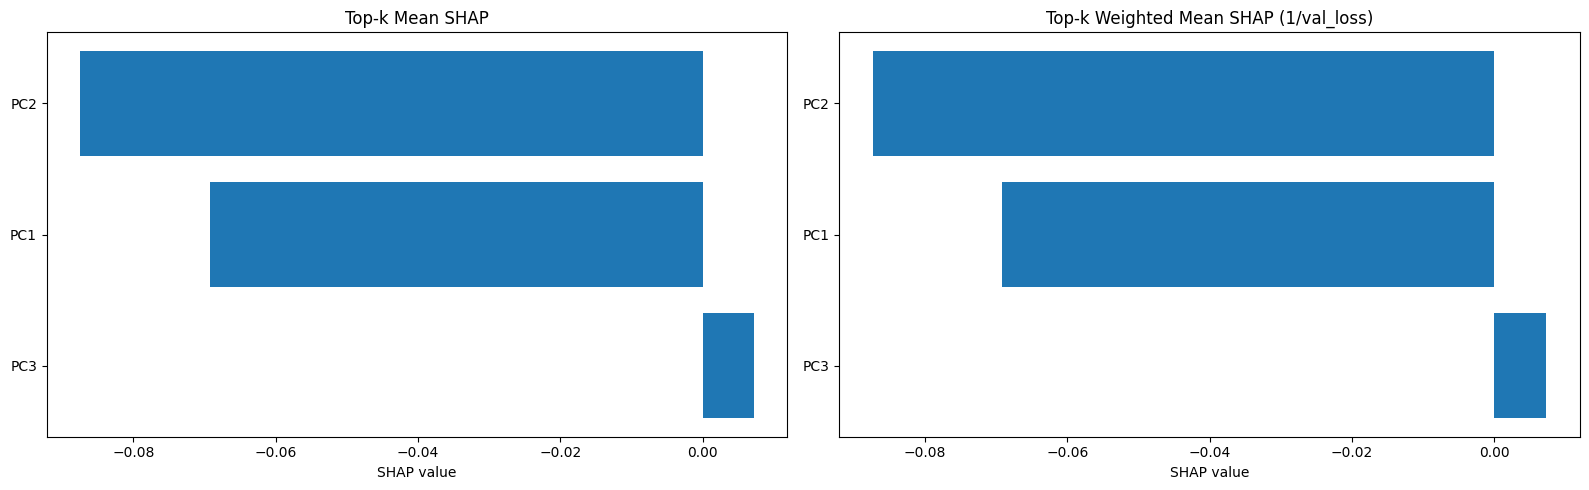

(  feature      shap  abs_shap
 1     PC2 -0.087433  0.087433
 0     PC1 -0.069224  0.069224
 2     PC3  0.007205  0.007205,
   feature      shap  abs_shap
 1     PC2 -0.087317  0.087317
 0     PC1 -0.069239  0.069239
 2     PC3  0.007281  0.007281)

In [ ]:
import importlib
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import shap

# ---------- Artifact selection ----------
artifacts_root = experiment_artifacts_root
run_name = 'fwd_ann_pcc_4runs_top2'
run_timestamp = None  # None -> use latest run for this run_name
# ---------------------------------------

# ---------- User selections ----------
agg_maturity = chosen_maturity if 'chosen_maturity' in globals() else '120'
agg_date = chosen_date if 'chosen_date' in globals() else None
agg_background_size = background_size if 'background_size' in globals() else 128
use_inverse_loss_weights = True
# ------------------------------------


def resolve_run_dir(base_dir: Path, run_name: str, run_timestamp: str | None = None) -> Path:
    run_root = base_dir / run_name
    if not run_root.exists():
        raise FileNotFoundError(f"Run root does not exist: {run_root}")

    if run_timestamp is not None:
        run_dir = run_root / run_timestamp
        if not run_dir.exists():
            raise FileNotFoundError(f"Requested run timestamp not found: {run_dir}")
        return run_dir

    candidates = sorted([p for p in run_root.iterdir() if p.is_dir()])
    if not candidates:
        raise FileNotFoundError(f"No timestamped runs found under: {run_root}")
    return candidates[-1]


run_dir = resolve_run_dir(artifacts_root, run_name, run_timestamp)
manifest = pd.read_csv(run_dir / 'checkpoint_manifest.csv')
topk_indices = np.load(run_dir / 'topk_indices.npy')
losses_arr_disk = np.load(run_dir / 'losses_arr.npy')

if agg_maturity not in maturities:
    raise ValueError(f"agg_maturity={agg_maturity} not found in maturities list")

m_idx = maturities.index(agg_maturity)

# Resolve date index for aggregation.
if agg_date is None:
    valid_t = np.where(topk_indices[:, m_idx, 0] >= 0)[0]
    if len(valid_t) == 0:
        raise RuntimeError("No valid top-k selection found for this maturity.")
    t_idx = int(valid_t[-1])
else:
    matches = np.where(pd.to_datetime(dates) == pd.Timestamp(agg_date))[0]
    if len(matches) == 0:
        raise ValueError(f"agg_date={agg_date} not found in `dates`.")
    t_idx = int(matches[0])

seed_candidates = topk_indices[t_idx, m_idx, :]
selected_seeds = [int(s) for s in seed_candidates if int(s) >= 0]

if len(selected_seeds) == 0:
    raise RuntimeError("No valid seeds in top-k for selected maturity/date.")


def _apply_saved_preprocessing_local(X_raw, scaler_state, pca_state):
    Xp = np.asarray(X_raw, dtype=np.float32).copy()

    if scaler_state is not None:
        mean = scaler_state.get('mean_', None)
        scale = scaler_state.get('scale_', None)

        if mean is not None:
            Xp = Xp - np.asarray(mean, dtype=np.float32)

        if scale is not None:
            scale = np.asarray(scale, dtype=np.float32)
            scale = np.where(scale == 0.0, 1.0, scale)
            Xp = Xp / scale

    if pca_state is not None and pca_state.get('components_', None) is not None:
        pca_mean = pca_state.get('mean_', None)
        if pca_mean is not None:
            Xp = Xp - np.asarray(pca_mean, dtype=np.float32)
        comps = np.asarray(pca_state['components_'], dtype=np.float32)
        Xp = Xp @ comps.T

    return Xp


seed_shap_rows = []
seed_losses = []

for seed in selected_seeds:
    row = manifest[(manifest['seed'] == seed) & (manifest['t_index'] == t_idx)]
    if row.empty:
        continue

    ckpt_path = Path(row.iloc[0]['checkpoint_path'])
    checkpoint = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    if checkpoint.get('wrapper_class') != 'PyTorchMLPWrapper':
        continue

    # Reconstruct network from stored weights.
    state_dict = checkpoint['torch_state_dict']
    linear_keys = [k for k, v in state_dict.items() if k.endswith('.weight') and getattr(v, 'ndim', 0) == 2]
    linear_keys = sorted(linear_keys, key=lambda k: int(k.split('.')[1]))
    if len(linear_keys) < 2:
        continue

    in_dim = int(state_dict[linear_keys[0]].shape[1])
    out_dim = int(state_dict[linear_keys[-1]].shape[0])
    hidden_arch = tuple(int(state_dict[k].shape[0]) for k in linear_keys[:-1])

    ann_mod = importlib.import_module('models.ann_vector_validation')
    NetworkCls = getattr(ann_mod, '_MLPNetwork')
    model = NetworkCls(input_dim=in_dim, archi=hidden_arch, output_dim=out_dim)
    model.load_state_dict(state_dict)
    model.eval()

    # Replay per-seed preprocessing and explain the single selected row.
    X_forward = X['forward'].values
    X_proc = _apply_saved_preprocessing_local(X_forward, checkpoint.get('x_scaler', None), checkpoint.get('pca', None))

    train_end = max(1, t_idx)
    bg_start = max(0, train_end - agg_background_size)
    X_bg = X_proc[bg_start:train_end]
    X_eval = X_proc[t_idx:t_idx + 1]

    if X_bg.shape[0] < 2:
        continue

    bg_tensor = torch.tensor(X_bg, dtype=torch.float32)
    eval_tensor = torch.tensor(X_eval, dtype=torch.float32)

    explainer = shap.DeepExplainer(model, bg_tensor)
    shap_values = explainer.shap_values(eval_tensor)

    # Pull SHAP vector for the chosen maturity/output node.
    if isinstance(shap_values, list):
        sv = np.asarray(shap_values[m_idx])[0]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        sv = shap_values[0, :, m_idx]
    else:
        sv = np.asarray(shap_values)[0]

    sv = np.asarray(sv, dtype=float).reshape(-1)
    seed_shap_rows.append(sv)

    # Validation loss at this date/seed/maturity, used for optional weighting.
    vloss = losses_arr_disk[t_idx, seed, m_idx]
    seed_losses.append(float(vloss) if np.isfinite(vloss) else np.nan)

if len(seed_shap_rows) == 0:
    raise RuntimeError("No seed SHAP vectors were computed for the selected setup.")

seed_shap_mat = np.vstack(seed_shap_rows)  # shape: (k_effective, n_features)

# Build feature names that match SHAP dimensionality.
raw_feature_names = [col if isinstance(col, str) else ' | '.join(map(str, col)) for col in X['forward'].columns]
if len(raw_feature_names) == seed_shap_mat.shape[1]:
    feature_names = raw_feature_names
else:
    feature_names = [f'PC{i+1}' for i in range(seed_shap_mat.shape[1])]

# Unweighted mean SHAP across top-k seeds.
mean_sv = np.nanmean(seed_shap_mat, axis=0)

# Optional weighted mean: weights proportional to 1 / validation_loss.
losses = np.asarray(seed_losses, dtype=float)
if use_inverse_loss_weights and np.isfinite(losses).any() and np.all(losses[np.isfinite(losses)] > 0):
    w = np.zeros_like(losses)
    good = np.isfinite(losses) & (losses > 0)
    w[good] = 1.0 / losses[good]
    if w.sum() > 0:
        w = w / w.sum()
        weighted_sv = np.nansum(seed_shap_mat * w[:, None], axis=0)
    else:
        weighted_sv = mean_sv.copy()
else:
    weighted_sv = mean_sv.copy()

plot_df_unweighted = pd.DataFrame({'feature': feature_names, 'shap': mean_sv, 'abs_shap': np.abs(mean_sv)})
plot_df_unweighted = plot_df_unweighted.sort_values('abs_shap', ascending=False).head(15)

plot_df_weighted = pd.DataFrame({'feature': feature_names, 'shap': weighted_sv, 'abs_shap': np.abs(weighted_sv)})
plot_df_weighted = plot_df_weighted.sort_values('abs_shap', ascending=False).head(15)

print('Run dir:', run_dir)
print('Selected date:', pd.Timestamp(dates[t_idx]).date())
print('Selected maturity:', agg_maturity)
print('Selected seeds:', selected_seeds)
print('Effective seeds used:', len(seed_shap_rows))
print('Input feature space for SHAP:', 'PCA components' if len(feature_names) != len(raw_feature_names) else 'Raw forward features')

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=False)
axes[0].barh(plot_df_unweighted['feature'].iloc[::-1], plot_df_unweighted['shap'].iloc[::-1])
axes[0].set_title('Mean SHAP across top-k seeds')
axes[0].set_xlabel('SHAP value')

axes[1].barh(plot_df_weighted['feature'].iloc[::-1], plot_df_weighted['shap'].iloc[::-1])
axes[1].set_title('Inverse-loss weighted SHAP')
axes[1].set_xlabel('SHAP value')

plt.tight_layout()
plt.show()

plot_df_unweighted